## 1. Import Libraries

In [68]:
import pandas as pd
import numpy as np

In [75]:

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


In [36]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

### 2. Read Dataset

In [37]:
import pandas as pd

TitanicNew = pd.read_csv(r"D:\NewFolder_Datasets\Titanic-Dataset.csv")

TitanicNew.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


### 3. Drop Unnecessary Columns

In [71]:
df = df.drop(columns=[
    'PassengerId',
    'Name',
    'Ticket',
    'Cabin'
])

### 4. Features & Target

In [72]:
X = df.drop('Survived',axis=1)

y = df['Survived']

### 5. Preprocessing

In [73]:
numeric_features = ['Age','Fare']

categorical_features = [
    'Sex',
    'Embarked',
    'Pclass'
]

Numeric Pipeline

In [76]:
numeric_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy='mean')),
    ('scaler',StandardScaler())
])

### Categorical Pipeline

In [77]:
categorical_transformer = Pipeline([
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
])

Combine

In [78]:
preprocessor = ColumnTransformer([
    ('num',numeric_transformer,numeric_features),
    ('cat',categorical_transformer,categorical_features)
],remainder='passthrough')

### 6. Train Test Split

In [79]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

### 7. Transform Data

In [80]:
X_train = preprocessor.fit_transform(X_train)

X_test = preprocessor.transform(X_test)

## Compare Multiple ML Algorithms

In [81]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score

Store Models

In [ ]:
models = {

    "Logistic Regression":
    LogisticRegression(max_iter=1000),

    "Decision Tree":
    DecisionTreeClassifier(),

    "Random Forest":
    RandomForestClassifier(),

    "Extra Trees":
    ExtraTreesClassifier(),

    "Gradient Boosting":
    GradientBoostingClassifier(),

    "AdaBoost":
    AdaBoostClassifier(),

    "HistGradientBoosting":
    HistGradientBoostingClassifier(),

    "KNN":
    KNeighborsClassifier(),

    "SVM":
    SVC(),

    "Naive Bayes":
    GaussianNB(),

    "MLP":
    MLPClassifier(max_iter=1000)
}

Train Every Algorithm

In [83]:
results = []

for name,model in models.items():

    model.fit(X_train,y_train)

    prediction = model.predict(X_test)

    accuracy = accuracy_score(y_test,prediction)

    results.append([name,accuracy])

c:\Users\Gopal Chavan\anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


Show Accuracy

In [84]:
result_df = pd.DataFrame(
    results,
    columns=['Algorithm','Accuracy']
)

result_df = result_df.sort_values(
    by='Accuracy',
    ascending=False
)

print(result_df)

               Algorithm  Accuracy
3            Extra Trees  0.826816
2          Random Forest  0.821229
10                   MLP  0.821229
4      Gradient Boosting  0.815642
6   HistGradientBoosting  0.815642
7                    KNN  0.810056
8                    SVM  0.810056
5               AdaBoost  0.804469
0    Logistic Regression  0.798883
1          Decision Tree  0.787709
9            Naive Bayes  0.770950


Bar Graph

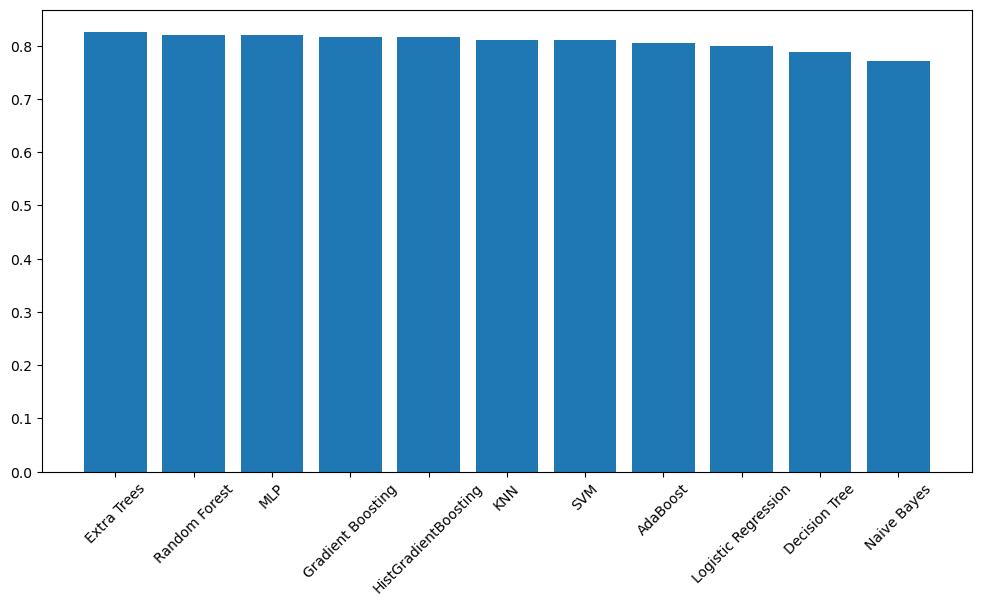

In [85]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(result_df['Algorithm'],
        result_df['Accuracy'])

plt.xticks(rotation=45)

plt.show()

Evaluate Best Model

In [86]:
best_model = RandomForestClassifier()

best_model.fit(X_train,y_train)

prediction = best_model.predict(X_test)

Accuracy

In [87]:
from sklearn.metrics import accuracy_score

accuracy_score(y_test,prediction)

0.8100558659217877

Confusion Matrix

In [88]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,prediction)

print(cm)

[[90 15]
 [19 55]]


Classification Report

In [89]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    prediction
))

              precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



Cross Validation

In [90]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    RandomForestClassifier(),
    X_train,
    y_train,
    cv=10
)

print(scores)

print(scores.mean())

[0.81944444 0.76388889 0.73239437 0.81690141 0.8028169  0.78873239
 0.78873239 0.76056338 0.77464789 0.87323944]
0.7921361502347418


Hyperparameter Tuning (Grid Search)

In [91]:
from sklearn.model_selection import GridSearchCV

params = {

    'n_estimators':[100,200,300],

    'max_depth':[3,5,10,None],

    'min_samples_split':[2,5,10]
}

grid = GridSearchCV(

    RandomForestClassifier(),

    params,

    cv=5,

    scoring='accuracy'
)

grid.fit(X_train,y_train)

print(grid.best_params_)

print(grid.best_score_)

{'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 200}
0.8244065793361568


In [ ]:
print(np.argwhere(np.isnan(x_train_t)))

[[549   6]]


### logistic regression learning

In [38]:
TitanicNew = TitanicNew.drop(columns=['PassengerId','Name','Ticket','Cabin'])

In [39]:
TitanicNew.isnull().sum()

Survived      0
Pclass        0
Sex           0
Age         177
SibSp         0
Parch         0
Fare          0
Embarked      2
dtype: int64

In [40]:
TitanicNew.dtypes

Survived      int64
Pclass        int64
Sex          object
Age         float64
SibSp         int64
Parch         int64
Fare        float64
Embarked     object
dtype: object

In [41]:
TitanicNew['Embarked'] = data['Embarked'].fillna(data['Embarked'].mode()[0])

In [42]:
TitanicNew['Embarked'] = data['Embarked'].map({'S':0, 'C':1, 'Q':2})


In [43]:
transformer = ColumnTransformer(transformers=[
    ('tnf1',OneHotEncoder(drop='if_binary', sparse_output=False), ['Sex']),
    ('tnf2',SimpleImputer(),['Age'])
],remainder='passthrough')

In [44]:
X = TitanicNew.drop(columns=['Survived'])
y = TitanicNew['Survived']
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,male,22.0,1,0,7.2500,0.0
1,1,female,38.0,1,0,71.2833,1.0
2,3,female,26.0,0,0,7.9250,0.0
3,1,female,35.0,1,0,53.1000,0.0
4,3,male,35.0,0,0,8.0500,0.0


In [45]:
import numpy as np

print(np.isnan(x_train_t).sum())

1


In [46]:
print(np.argwhere(np.isnan(x_train_t)))

[[549   6]]


In [47]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

x_train_t = imputer.fit_transform(x_train_t)
x_test_t = imputer.transform(x_test_t)

In [48]:
print(x_train_t[549, 6])

0.36849507735583686


In [49]:
col_mean = np.nanmean(x_train_t[:, 6])

x_train_t[549, 6] = col_mean

In [50]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_t, y_train)

LogisticRegression(max_iter=1000)

In [51]:
print(type(x_train_t))
print(x_train_t.shape)
print(np.isnan(x_train_t).sum())

print(type(y_train))
print(y_train.shape)

<class 'numpy.ndarray'>
(712, 7)
0
<class 'pandas.core.series.Series'>
(712,)


In [52]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=40)

In [53]:
x_train_t = transformer.fit_transform(X_train)
x_test_t = transformer.transform(X_test)

In [55]:
import numpy as np

print("NaNs in x_train_t:", np.isnan(x_train_t).sum())
print("NaNs in y_train:", np.isnan(y_train).sum() if hasattr(y_train, "dtype") else "Cannot check")

NaNs in x_train_t: 1
NaNs in y_train: 0


In [56]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="mean")

x_train_t = imputer.fit_transform(x_train_t)

In [57]:
print(np.isnan(x_train_t).sum())

0


In [59]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr.fit(x_train_t, y_train)

LogisticRegression(max_iter=1000)

In [66]:
y_predict = lr.predict(x_test_t)


In [61]:
import numpy as np

print("NaNs in x_test_t:", np.isnan(x_test_t).sum())

NaNs in x_test_t: 1


In [62]:
print(np.argwhere(np.isnan(x_test_t)))

[[129   6]]


### 1. Fill missing values


In [ ]:
from sklearn.impute import SimpleImputer
# 1. Fill missing values

imputer = SimpleImputer(strategy="mean")

# Fit only on training data
x_train_t = imputer.fit_transform(x_train_t)

# Transform test data using the same imputer
x_test_t = imputer.transform(x_test_t)

###  Train


In [64]:
print(np.isnan(x_train_t).sum())
print(np.isnan(x_test_t).sum())

0
0


###  Predict


In [65]:
y_predict = lr.predict(x_test_t)

In [67]:
from sklearn.metrics import accuracy_score, confusion_matrix
print(accuracy_score(y_test,y_predict))
print(confusion_matrix(y_test,y_predict))

0.8156424581005587
[[87 16]
 [17 59]]
